# Phase 1: Data Collection & EDA

**Project:** YouTube Toxic Comment Detector (`ai-nlp`)

**Goals (AGENTS.md Phase 1):**
- Load and audit dataset structure, missing values, text length
- **Safe vs Toxic** distribution (`IsToxic`)
- Multilabel EDA and sparse-label viability
- Metric and augmentation recommendations

## Environment (`uv`)

From repository root **`ai-nlp`** / **`.`**:

```bash
uv sync
uv run jupyter notebook notebooks/phase1_data_collection_eda.ipynb
```

All Python in this project runs via **`uv run`** (see AGENTS.md).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data.loader import load_processed_data
from src.evaluation.phase1_audit import (
    BINARY_TARGET,
    DEFAULT_RANDOM_STATE,
    DEFAULT_TEST_SIZE,
    augmentation_recommendation,
    audit_structure,
    label_cooccurrence,
    label_strategy_decision,
    missing_report,
    multilabel_positive_counts,
    recommended_metrics,
    safe_vs_toxic_distribution,
    save_phase1_summary,
    sparse_label_report,
    stratified_label_split,
    text_length_stats,
)
from src.utils.execution_log import log_event

DATA_PATH = ROOT / "data/raw/youtoxic_english_1000.csv"
REPORT_DIR = ROOT / "reports/phase1"
LOG_PATH = ROOT / "logs/execution.log"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
MIN_TRAIN_POSITIVES = 5

log_event("Phase 1 EDA notebook started", phase="1", log_path=LOG_PATH)


## 1. Load Data

In [2]:
df, label_cols = load_processed_data(str(DATA_PATH))
structure = audit_structure(df)
print("Structure audit:")
for k, v in structure.items():
    if k != "dtypes":
        print(f"  {k}: {v}")
df.head()

Structure audit:
  n_rows: 1000
  n_cols: 13
  columns: ['Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']
  memory_mb: 0.29


,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,If only people would just take a step back and...,0,0,0,0,0,0,0,0,0,0,0,0
1,Law enforcement is not trained to shoot to app...,1,1,0,0,0,0,0,0,0,0,0,0
2,\nDont you reckon them 'black lives matter' ba...,1,1,0,0,1,0,0,0,0,0,0,0
3,There are a very large number of people who do...,0,0,0,0,0,0,0,0,0,0,0,0
4,"The Arab dude is absolutely right, he should h...",0,0,0,0,0,0,0,0,0,0,0,0


## 2. Missing Values & Duplicates

In [3]:
missing_df = missing_report(df)
print("Missing values per column:")
display(missing_df)

dup_text = df["Text"].duplicated().sum()
empty_text = (df["Text"].astype(str).str.strip() == "").sum()
print(f"Duplicate Text rows: {dup_text}")
print(f"Empty Text rows: {empty_text}")

Missing values per column:


,missing,pct
Text,0,0.0
IsToxic,0,0.0
IsAbusive,0,0.0
IsThreat,0,0.0
IsProvocative,0,0.0
IsObscene,0,0.0
IsHatespeech,0,0.0
IsRacist,0,0.0
IsNationalist,0,0.0
IsSexist,0,0.0


Duplicate Text rows: 3
Empty Text rows: 0


## 3. Text Length

Text length summary:
char_len_mean       185.55
char_len_median     101.00
char_len_max       4421.00
char_len_min          3.00
word_len_mean        33.78
word_len_median      19.00


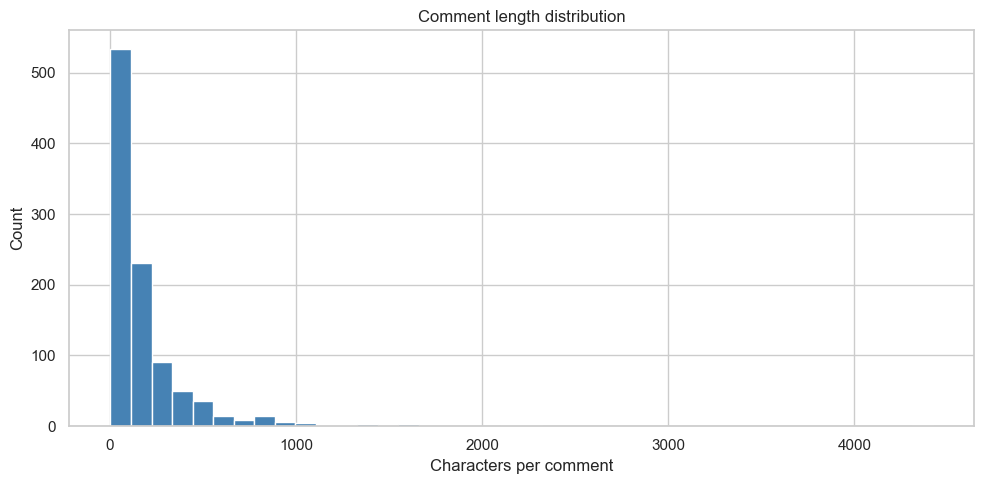

Saved: /Users/miraekang/proyectos/ai-nlp/reports/phase1/text_length_hist.png


In [4]:
length_stats = text_length_stats(df)
print("Text length summary:")
print(length_stats.to_string())

char_len = df["Text"].astype(str).str.len()
fig, ax = plt.subplots()
ax.hist(char_len, bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Characters per comment")
ax.set_ylabel("Count")
ax.set_title("Comment length distribution")
plt.tight_layout()
fig_path = REPORT_DIR / "text_length_hist.png"
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Saved: {fig_path}")

## 4. Safe vs Toxic (Default Target: `IsToxic`)

Safe vs Toxic distribution:


,class,IsToxic,count,pct
0,Safe,0,538,53.8
1,Toxic,1,462,46.2


Imbalance ratio (majority/minority): 1.16
Minority class: Toxic
Recommended primary metrics: ['Accuracy', 'F1-score (Toxic class)']


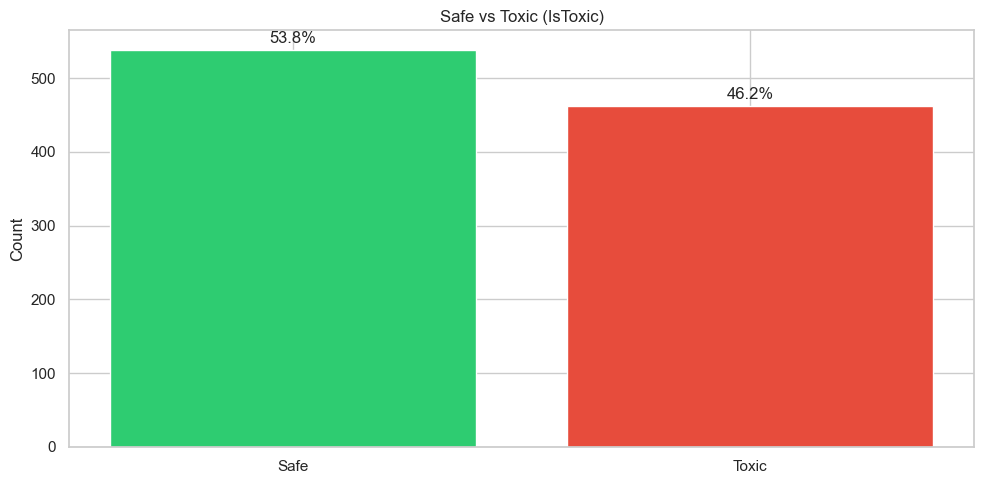

In [5]:
binary_dist = safe_vs_toxic_distribution(df)
print("Safe vs Toxic distribution:")
display(binary_dist)

imbalance_ratio = binary_dist.attrs.get("imbalance_ratio", 1.0)
minority = binary_dist.attrs.get("minority_class", "Toxic")
toxic_row = binary_dist[binary_dist["class"] == "Toxic"]
toxic_pct = float(toxic_row["pct"].iloc[0]) if len(toxic_row) else 0.0

metrics = recommended_metrics(imbalance_ratio)
print(f"Imbalance ratio (majority/minority): {imbalance_ratio}")
print(f"Minority class: {minority}")
print(f"Recommended primary metrics: {metrics}")

fig, ax = plt.subplots()
ax.bar(binary_dist["class"], binary_dist["count"], color=["#2ecc71", "#e74c3c"])
ax.set_ylabel("Count")
ax.set_title("Safe vs Toxic (IsToxic)")
for i, row in binary_dist.iterrows():
    ax.text(i, row["count"] + 10, f"{row['pct']}%", ha="center")
plt.tight_layout()
bar_path = REPORT_DIR / "safe_vs_toxic.png"
plt.savefig(bar_path, dpi=120)
plt.show()

## 2b. Stratified Train/Test Split (label viability on train)


In [6]:
df_train, df_test, y_train, y_test = stratified_label_split(
    df, label_cols, test_size=DEFAULT_TEST_SIZE, random_state=DEFAULT_RANDOM_STATE
)
print(
    f"Stratified split: train={len(df_train)}, test={len(df_test)} "
    f"(test_size={DEFAULT_TEST_SIZE}, random_state={DEFAULT_RANDOM_STATE})"
)
log_event(
    f"Phase 1 stratified split train={len(df_train)} test={len(df_test)}",
    phase="1",
    log_path=LOG_PATH,
)


Stratified split: train=800, test=200 (test_size=0.2, random_state=42)


## 5. Multilabel EDA & Sparse Labels

Full-dataset positive counts (reference):
IsToxic            462
IsAbusive          353
IsProvocative      161
IsHatespeech       138
IsRacist           125
IsObscene          100
IsThreat            21
IsReligiousHate     12
IsNationalist        8
IsSexist             1
IsHomophobic         0
IsRadicalism         0

Sparse label report (train positives >= 5):


,label,subset,positives,viable_multilabel
0,IsToxic,train,370,True
1,IsAbusive,train,282,True
2,IsProvocative,train,133,True
3,IsHatespeech,train,114,True
4,IsRacist,train,105,True
5,IsObscene,train,85,True
6,IsThreat,train,14,True
7,IsReligiousHate,train,7,True
8,IsNationalist,train,6,True
9,IsSexist,train,1,False


Viable for multilabel on TRAIN: 9 labels
Too sparse on TRAIN: ['IsSexist', 'IsHomophobic', 'IsRadicalism']


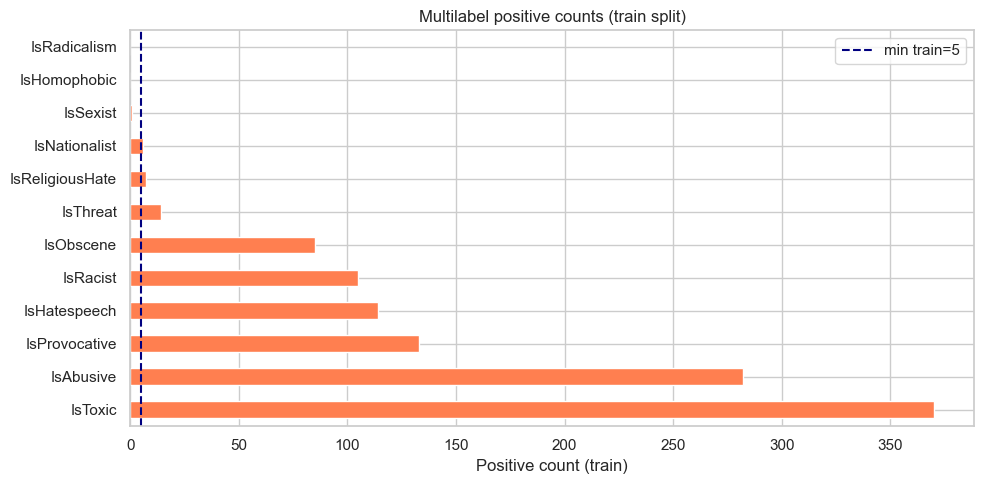

Saved: /Users/miraekang/proyectos/ai-nlp/reports/phase1/multilabel_counts_train.png


In [7]:
label_counts_full = multilabel_positive_counts(df, label_cols)
print("Full-dataset positive counts (reference):")
print(label_counts_full.to_string())

sparse_df = sparse_label_report(
    y_train, label_cols, min_positives=MIN_TRAIN_POSITIVES, subset_name="train"
)
print(f"\nSparse label report (train positives >= {MIN_TRAIN_POSITIVES}):")
display(sparse_df)

sparse_labels = sparse_df.loc[~sparse_df["viable_multilabel"], "label"].tolist()
viable_labels = sparse_df.loc[sparse_df["viable_multilabel"], "label"].tolist()
print(f"Viable for multilabel on TRAIN: {len(viable_labels)} labels")
print(f"Too sparse on TRAIN: {sparse_labels}")

label_counts = multilabel_positive_counts(y_train, label_cols)

fig, ax = plt.subplots(figsize=(10, 5))
label_counts.plot(kind="barh", ax=ax, color="coral")
ax.axvline(MIN_TRAIN_POSITIVES, color="navy", linestyle="--", label=f"min train={MIN_TRAIN_POSITIVES}")
ax.set_xlabel("Positive count (train)")
ax.set_title("Multilabel positive counts (train split)")
ax.legend()
plt.tight_layout()
ml_path = REPORT_DIR / "multilabel_counts_train.png"
plt.savefig(ml_path, dpi=120)
plt.show()
print(f"Saved: {ml_path}")


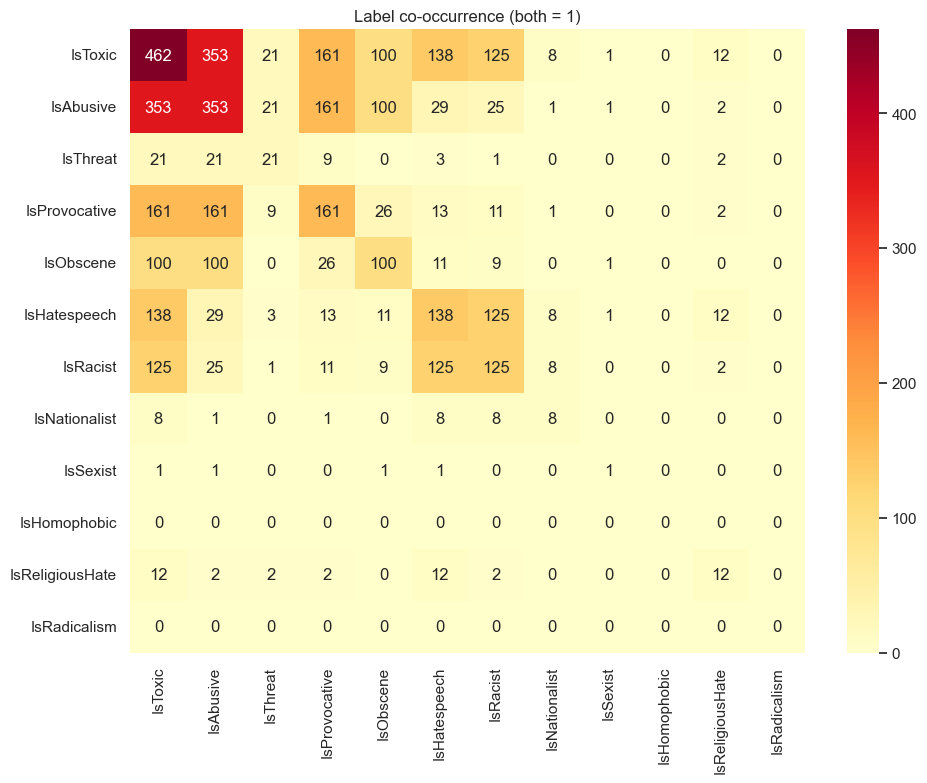

In [8]:
cooc = label_cooccurrence(df, label_cols)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Label co-occurrence (both = 1)")
plt.tight_layout()
co_path = REPORT_DIR / "label_cooccurrence.png"
plt.savefig(co_path, dpi=120)
plt.show()

## 6. Augmentation Planning

In [9]:
strategy = label_strategy_decision(viable_labels, sparse_labels)
aug = augmentation_recommendation(len(df), toxic_pct, sparse_labels)
print("Label strategy:")
for k, v in strategy.items():
    print(f"  {k}: {v}")
print("\nAugmentation recommendation:")
for k, v in aug.items():
    print(f"  {k}: {v}")


Label strategy:
  esencial_target: binary IsToxic (Safe vs Toxic)
  medio_plus_strategy: Proceed with multilabel subset in Medio+
  default_target: IsToxic

Augmentation recommendation:
  augmentation_recommended: True
  reason: Small dataset, class imbalance, and/or many sparse multilabel dimensions.
  techniques: ['Synonym replacement (nlpaug)', 'Back-translation (optional)']
  default_target: IsToxic


In [10]:
summary = {
    "phase": 1,
    "dataset": str(DATA_PATH.name),
    "structure": structure,
    "train_test_split": {
        "test_size": DEFAULT_TEST_SIZE,
        "random_state": DEFAULT_RANDOM_STATE,
        "n_train": len(df_train),
        "n_test": len(df_test),
    },
    "missing_total": int(missing_df["missing"].sum()),
    "duplicate_text": int(dup_text),
    "text_length": length_stats.to_dict(),
    "safe_vs_toxic": binary_dist.to_dict(orient="records"),
    "imbalance_ratio": imbalance_ratio,
    "recommended_metrics": metrics,
    "multilabel_positives_full": label_counts_full.to_dict(),
    "multilabel_positives_train": label_counts.to_dict(),
    "sparse_labels_train": sparse_labels,
    "viable_multilabel_labels_train": viable_labels,
    "augmentation": aug,
    **strategy,
}
json_path = save_phase1_summary(summary, REPORT_DIR / "phase1_summary.json")
log_event(f"Phase 1 summary saved to {json_path}", phase="1", log_path=LOG_PATH)
print(f"Saved summary: {json_path}")


Saved summary: /Users/miraekang/proyectos/ai-nlp/reports/phase1/phase1_summary.json


## Conclusion

Phase 1 EDA on **`youtoxic_english_1000.csv`** (stratified train/test per AGENTS.md):

- **Data quality:** No missing values; duplicate `Text` rows documented in run output.
- **Safe vs Toxic (`IsToxic`):** Distribution and metrics in outputs above; **Esencial = binary Safe vs Toxic**.
- **Multilabel:** Viability assessed on **train split** (min positives ≥ 5); sparse train labels listed in summary JSON.
- **Medio+:** Multilabel subset only if train viability and strategy dict allow; otherwise stay binary.
- **Augmentation:** See run output; Phase 2 may apply synonym / back-translation if recommended.
- **Tooling:** Run with `uv sync` and `uv run jupyter notebook`; log in `logs/execution.log`.
- **Artifacts:** `reports/phase1/phase1_summary.json` and PNG charts.


In [11]:
print("=" * 60)
print("PHASE 1 — KEY FINDINGS")
print("=" * 60)
print(f"Rows: {structure['n_rows']} | Train: {len(df_train)} | Test: {len(df_test)}")
print(f"Missing values (all columns): {int(missing_df['missing'].sum())}")
print(f"Text length (mean chars): {length_stats['char_len_mean']}")
print("\nSafe vs Toxic (IsToxic, full data):")
print(binary_dist.to_string(index=False))
print(f"Imbalance ratio: {imbalance_ratio} → metrics: {metrics}")
print(f"\nEsencial: {strategy['esencial_target']}")
print(f"Medio+: {strategy['medio_plus_strategy']}")
print(f"Sparse on TRAIN (<{MIN_TRAIN_POSITIVES}): {sparse_labels}")
print(f"Augmentation recommended: {aug['augmentation_recommended']} — {aug['reason']}")
print(f"\nArtifacts: {REPORT_DIR}/")
print(f"Log: {LOG_PATH}")
print("=" * 60)
log_event("Phase 1 EDA notebook completed", phase="1", log_path=LOG_PATH)


PHASE 1 — KEY FINDINGS
Rows: 1000 | Train: 800 | Test: 200
Missing values (all columns): 0
Text length (mean chars): 185.55

Safe vs Toxic (IsToxic, full data):
class  IsToxic  count  pct
 Safe        0    538 53.8
Toxic        1    462 46.2
Imbalance ratio: 1.16 → metrics: ['Accuracy', 'F1-score (Toxic class)']

Esencial: binary IsToxic (Safe vs Toxic)
Medio+: Proceed with multilabel subset in Medio+
Sparse on TRAIN (<5): ['IsSexist', 'IsHomophobic', 'IsRadicalism']
Augmentation recommended: True — Small dataset, class imbalance, and/or many sparse multilabel dimensions.

Artifacts: /Users/miraekang/proyectos/ai-nlp/reports/phase1/
Log: /Users/miraekang/proyectos/ai-nlp/logs/execution.log
